# Welcome!
## What is this?

## Who this is for

## What you will learn

## What will not be covered

# The tiniest introduction
Bayesian modeling involves estimating...things. It is intellectually satisfying (link), very flexible (if you can imagine it, and it makes sense, you can model it), and, with a modern software stack, not too painful.

This short course isn't theory-then-implementation. It's intermixed.

Bayesian models have priors, which are beliefs about a quantity, for things that are estimated. They have estimated quantities, assumptions, and data. What we want to do, fundamentally, is estimate the probability of some parameter, or model, given our assumptions, priors, and some data.

# A First Example: Means
Suppose we have a little bit of continuous data. Let's assume that it was sourced in some way that makes it iid (link), which basically just means "with no biases from how it was sourced."

Let's estimate the mean and standard deviation of the distribution that gave rise to that data.

### A note
Throughout this course, we will use some simulated (i.e. made up) data for demonstrative purposes, and some real data to show how complicated things can get. Overall, we should expect our model(s) to recover our simulated parameters pretty well ;)

In [3]:
# Simulate some data:
import numpy as np

# -----------------------------
# 1. Make a small sample of continuous data
# -----------------------------
rng = np.random.default_rng(99)


simulated_population_mean = 10.0
simulated_population_sd = 2.0
n = 12

y = rng.normal(loc=simulated_population_mean, scale=simulated_population_sd, size=n)

print("Sample:", np.round(y, 2))



Sample: [10.16  9.07 10.1  11.37  6.49 13.37  9.08  8.81  7.91 11.86 11.35 12.49]


In [4]:
# Let's estimate the mean and sd, in the 'normal'/frequentist manner
sample_mean = np.mean(y)
sample_sd = np.std(y, ddof=1)   # sample SD

print(f"Frequentist sample mean: {sample_mean:.3f}")
print(f"Frequentist sample SD:   {sample_sd:.3f}")

Frequentist sample mean: 10.172
Frequentist sample SD:   2.006


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [mu]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 0 seconds.


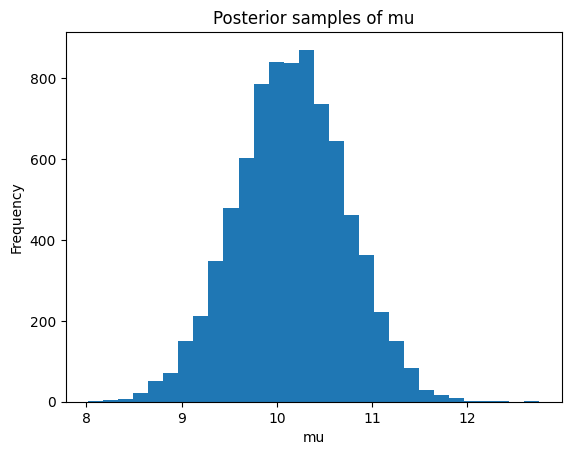

In [10]:
# Now, let's write a Bayesian model of the mean
# At first, we'll assume we know the sd (just for demo)
# We will set up a PyMC model
# We will structure assumptions:
#   - there is some population model, and it's Guassian (Normal)
#   - there is a population sd, and we know it
#   - our observations come from this model
# We will set up an MCMC sampler, and draw samples from it

import pymc as pm # our Bayesian MCMC workhorse
import arviz as az # a viz tool that is moderately coupled with pymc
import matplotlib.pyplot as plt # for plots

known_sigma = simulated_population_sd

with pm.Model() as model_known_sigma: # how you set up a pymc model...
    # this is a paramter we want to estimate...
    # variable is called mu, and it's named "mu" so we can access it later
    # formally, this is both a prior on mu, and also telling PyMC how to track it
    # In English: There is a variable called mu, which we can use as mu, and
    #    our prior on it is normally distributed, with mean zero and sigma 20
    #    (that is, extremely diffuse or uninformative. 
    mu = pm.Normal("mu", mu=0, sigma=20) 

    # We think our observations are drawn from a Normal distribution...
    # with mean 'mu' (from above!) and sigma 'our known sigma'
    # Our data, the "obs" vector, is noted as the input to this Normal
    # The prior for the mean term of this normal is mu, from above.
    obs = pm.Normal("obs", mu=mu, sigma=known_sigma, observed=y)

    # Here is a simple sampler setup
    mcmc_samples_mod1 = pm.sample(
        draws=2000, # we will take 'enough' draws, more on this later
        tune=2000, # we will 'warm up' the sampler and throw those draws away; more on this later
        chains=4, # we will have 4 chains (i.e. parallel sampler); more on this later too :)
        target_accept=0.9, # a detail we describe in another notebook
        random_seed=99,
        progressbar=False # no need to watch this
    )


# Let's take a look at how to extract our samples, and visualize them
mu_samples = mcmc_samples_mod1.posterior["mu"].values.flatten() # grab samples of mu
# Histogram of the samples of mu, our estimate of the mean of the population distribution
plt.hist(mu_samples, bins=30)
plt.xlabel("mu")
plt.ylabel("Frequency")
plt.title("Posterior samples of mu")
plt.show()



# Wait, huh?
Ok, let's walk through that first model again, to make sure we understand the code, and to keep building up our intiution about what's going on.

We want an estimate of the mean of the distribution that gave rise to our data. That distribution we are *assuming* to be Normal/Gaussian 'obs = pm.Normal(...' . That distribution has two parameters, and mean and a standard deviation. We are assuming we know the sd (very weird to assume, just for demonstrative purposes) and we want to estimate the mean.

We put a prior on that paramters 'mu = pm.Normal(...' that is very vague/non-informative.

Now our model is complete: we have an assumed structure (Normal distribution, fixed sd, data assumed to come from that Normal, prios on parameters we want to estimate).

We set up an MCMC sampler 'mcmc_samples_mod1 = pm.sample(...' , or rather, PyMC did that for us pretty much (no math on our end!) and ran it.

We then graphed the samples from that sampler, and can take quantities from them (mean, median, percentiles) to describe the distribution if we need statistics from it, rather than a complete histogram.

And, how did we do? Did our model recover a reasonable estimate of the true mean? Seems like it!

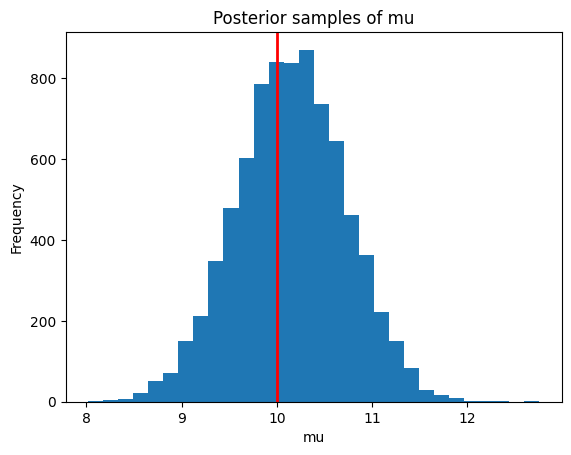

In [12]:
# Histogram of the samples, again
plt.hist(mu_samples, bins=30)

# Red line of the true mean of the population distribution
plt.axvline(simulated_population_mean, color="red", linewidth=2)

plt.xlabel("mu")
plt.ylabel("Frequency")
plt.title("Posterior samples of mu")
plt.show()